In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path

BASE_DIR = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test-llama")

# Define experiments: key is folder name, value contains metadata
experiments = {
    # Request Rate 1 (1.0 -> 0.5 req/s)
    'test-{kernel=direct}-{pp=48-32}-{rr=1}-{mig=0}-{in=512}-{out=16}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=1}': {
        'name': 'No Migration (rr=1)', 'rr': 1, 'migration': False, 'request_rates': [1.0, 0.5]
    },
    'test-{kernel=direct}-{pp=36-44}-{rr=1}-{mig=1}-{in=512}-{out=16}-{n_req=200}-{rep=1}-{chunk=40}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=1}': {
        'name': 'With Migration (rr=1)', 'rr': 1, 'migration': True, 'request_rates': [1.0, 0.5]
    },
    # Request Rate 2 (2.0 -> 1.5 req/s)
    'test-{kernel=direct}-{pp=48-32}-{rr=2}-{mig=0}-{in=512}-{out=16}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=1}': {
        'name': 'No Migration (rr=2)', 'rr': 2, 'migration': False, 'request_rates': [2.0, 1.5]
    },
    'test-{kernel=direct}-{pp=40-40}-{rr=2}-{mig=1}-{in=512}-{out=16}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=1}': {
        'name': 'With Migration (rr=2)', 'rr': 2, 'migration': True, 'request_rates': [2.0, 1.5]
    },
    # Request Rate 3 (3.0 -> 2.5 req/s)
    'test-{kernel=direct}-{pp=48-32}-{rr=3}-{mig=0}-{in=512}-{out=16}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=1}': {
        'name': 'No Migration (rr=3)', 'rr': 3, 'migration': False, 'request_rates': [3.0, 2.5]
    },
    'test-{kernel=direct}-{pp=48-32}-{rr=3}-{mig=1}-{in=512}-{out=16}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=1}': {
        'name': 'With Migration (rr=3)', 'rr': 3, 'migration': True, 'request_rates': [3.0, 2.5]
    },
}

# Load data
data = {}
for folder, meta in experiments.items():
    csv_path = BASE_DIR / folder / "request_metrics.csv"
    cfg_path = BASE_DIR / folder / "benchmark_config.json"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df['experiment'] = meta['name']
        df['rr'] = meta['rr']
        df['migration'] = meta['migration']
        
        # Load config for input/output lens
        with open(cfg_path) as f:
            cfg = json.load(f)
        meta['input_output_lens'] = cfg.get('input_output_lens', [[512, 16]])
        
        data[meta['name']] = {'df': df, 'meta': meta, 'folder': folder}
        print(f"Loaded {meta['name']}: {len(df)} requests")
    else:
        print(f"Warning: {csv_path} not found")


Loaded No Migration (rr=1): 200 requests
Loaded With Migration (rr=1): 200 requests
Loaded No Migration (rr=2): 200 requests
Loaded With Migration (rr=2): 200 requests
Loaded No Migration (rr=3): 200 requests
Loaded With Migration (rr=3): 200 requests


In [3]:
# Calculate metrics for each experiment
def calculate_metrics(df, meta):
    """Calculate comprehensive metrics for an experiment."""
    # Total duration: from first request start to last request finish
    total_time = (df['timestamp'] + df['e2els']).max() - df['timestamp'].min()
    
    # Calculate total tokens based on actual output lens patterns
    input_output_lens = meta['input_output_lens']
    # Assuming first 100 requests use first pattern, next 100 use second
    n_requests = len(df)
    tokens_per_pattern = n_requests // len(input_output_lens)
    total_tokens = sum(
        tokens_per_pattern * (io[0] + io[1]) for io in input_output_lens
    )
    
    # Normalized latency = e2e latency / output tokens
    # For each request, we need to estimate output tokens
    # First half uses first pattern, second half uses second
    half_n = n_requests // 2
    output_tokens_list = (
        [input_output_lens[0][1]] * half_n + 
        [input_output_lens[1][1]] * (n_requests - half_n)
    )
    df_copy = df.copy()
    df_copy['output_tokens'] = output_tokens_list
    df_copy['normalized_latency'] = df_copy['e2els'] / df_copy['output_tokens']
    
    return {
        'Avg TTFT (s)': df['ttfts'].mean(),
        'P50 TTFT (s)': df['ttfts'].median(),
        'P99 TTFT (s)': df['ttfts'].quantile(0.99),
        'Avg Normalized Latency (s/token)': df_copy['normalized_latency'].mean(),
        'P50 Normalized Latency (s/token)': df_copy['normalized_latency'].median(),
        'P99 Normalized Latency (s/token)': df_copy['normalized_latency'].quantile(0.99),
        'Throughput (tokens/s)': total_tokens / total_time if total_time > 0 else 0,
        'Total Time (s)': total_time,
        'Num Requests': n_requests,
    }

# Build summary for all experiments
summary_data = []
for name, exp_data in data.items():
    metrics = calculate_metrics(exp_data['df'], exp_data['meta'])
    metrics['Experiment'] = name
    metrics['RR'] = exp_data['meta']['rr']
    metrics['Migration'] = exp_data['meta']['migration']
    metrics['Request Rates'] = '/'.join(map(str, exp_data['meta']['request_rates']))
    summary_data.append(metrics)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values(['RR', 'Migration'])
print(summary_df[['Experiment', 'RR', 'Request Rates', 'Avg TTFT (s)', 'Avg Normalized Latency (s/token)', 'Throughput (tokens/s)']].to_string(index=False))


           Experiment  RR Request Rates  Avg TTFT (s)  Avg Normalized Latency (s/token)  Throughput (tokens/s)
  No Migration (rr=1)   1       1.0/0.5      0.376714                          0.112890             335.085476
With Migration (rr=1)   1       1.0/0.5      0.365198                          0.108547             337.599316
  No Migration (rr=2)   2       2.0/1.5      0.651627                          0.351782             689.975180
With Migration (rr=2)   2       2.0/1.5      0.609365                          0.296438             702.576556
  No Migration (rr=3)   3       3.0/2.5      4.108022                          0.964060             917.710239
With Migration (rr=3)   3       3.0/2.5      4.091229                          0.950788             948.685723


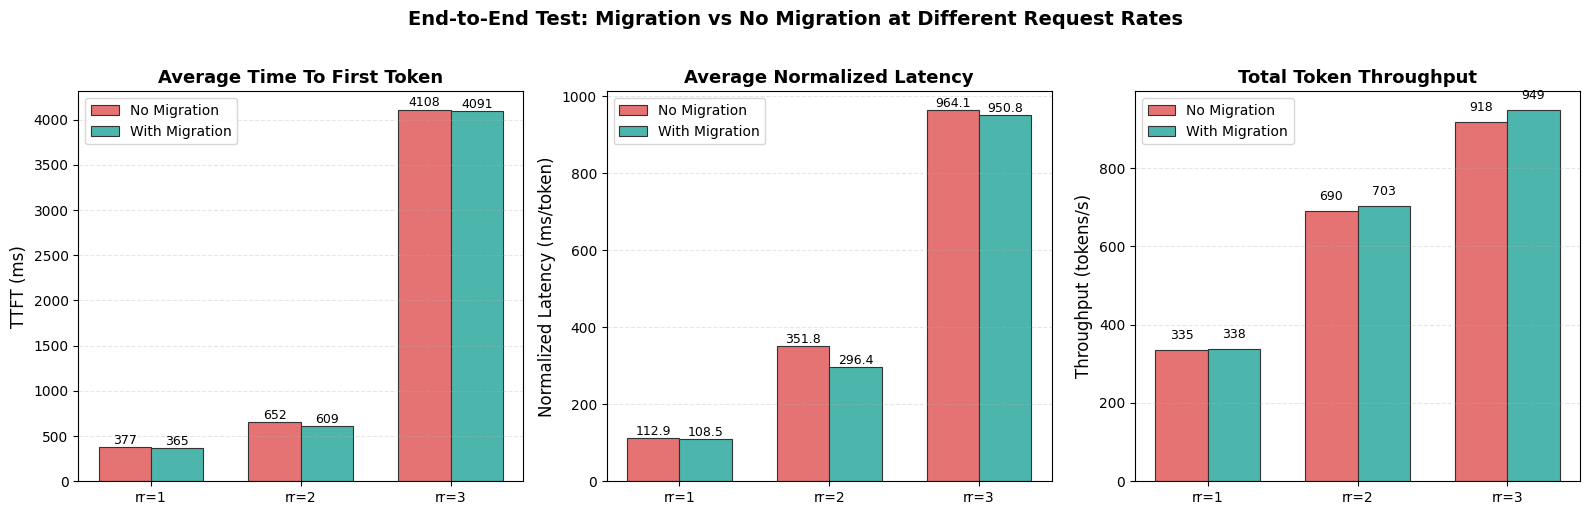

In [4]:
# Create grouped bar charts comparing Migration vs No Migration across request rates
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Prepare data for plotting
request_rates = sorted(summary_df['RR'].unique())
rr_labels = [f"rr={rr}" for rr in request_rates]

# Get metrics for each group
no_mig = summary_df[summary_df['Migration'] == False].sort_values('RR')
with_mig = summary_df[summary_df['Migration'] == True].sort_values('RR')

# Check which request rates have both migration and no-migration data
common_rrs = set(no_mig['RR'].tolist()) & set(with_mig['RR'].tolist())
common_rrs = sorted(common_rrs)

x = np.arange(len(common_rrs))
width = 0.35

colors_no_mig = '#E57373'  # Soft red
colors_mig = '#4DB6AC'     # Teal

# 1. TTFT comparison
ax1 = axes[0]
ttft_no_mig = no_mig[no_mig['RR'].isin(common_rrs)].sort_values('RR')['Avg TTFT (s)'].values * 1000  # Convert to ms
ttft_mig = with_mig[with_mig['RR'].isin(common_rrs)].sort_values('RR')['Avg TTFT (s)'].values * 1000

bars1_nm = ax1.bar(x - width/2, ttft_no_mig, width, label='No Migration', color=colors_no_mig, edgecolor='#333', linewidth=0.8)
bars1_m = ax1.bar(x + width/2, ttft_mig, width, label='With Migration', color=colors_mig, edgecolor='#333', linewidth=0.8)

ax1.set_ylabel('TTFT (ms)', fontsize=12)
ax1.set_title('Average Time To First Token', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f"rr={rr}" for rr in common_rrs], fontsize=10)
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars1_nm, ttft_no_mig):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars1_m, ttft_mig):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# 2. Normalized Latency comparison
ax2 = axes[1]
nl_no_mig = no_mig[no_mig['RR'].isin(common_rrs)].sort_values('RR')['Avg Normalized Latency (s/token)'].values * 1000  # ms/token
nl_mig = with_mig[with_mig['RR'].isin(common_rrs)].sort_values('RR')['Avg Normalized Latency (s/token)'].values * 1000

bars2_nm = ax2.bar(x - width/2, nl_no_mig, width, label='No Migration', color=colors_no_mig, edgecolor='#333', linewidth=0.8)
bars2_m = ax2.bar(x + width/2, nl_mig, width, label='With Migration', color=colors_mig, edgecolor='#333', linewidth=0.8)

ax2.set_ylabel('Normalized Latency (ms/token)', fontsize=12)
ax2.set_title('Average Normalized Latency', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"rr={rr}" for rr in common_rrs], fontsize=10)
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars2_nm, nl_no_mig):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2_m, nl_mig):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# 3. Throughput comparison
ax3 = axes[2]
tp_no_mig = no_mig[no_mig['RR'].isin(common_rrs)].sort_values('RR')['Throughput (tokens/s)'].values
tp_mig = with_mig[with_mig['RR'].isin(common_rrs)].sort_values('RR')['Throughput (tokens/s)'].values

bars3_nm = ax3.bar(x - width/2, tp_no_mig, width, label='No Migration', color=colors_no_mig, edgecolor='#333', linewidth=0.8)
bars3_m = ax3.bar(x + width/2, tp_mig, width, label='With Migration', color=colors_mig, edgecolor='#333', linewidth=0.8)

ax3.set_ylabel('Throughput (tokens/s)', fontsize=12)
ax3.set_title('Total Token Throughput', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f"rr={rr}" for rr in common_rrs], fontsize=10)
ax3.legend()
ax3.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars3_nm, tp_no_mig):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'{val:.0f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars3_m, tp_mig):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('End-to-End Test: Migration vs No Migration at Different Request Rates', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/e2e_llama_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [1]:
import json
import re
from pathlib import Path

import pandas as pd

LLAMA_BASE_DIR = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-config-cmp-with-mig-2")
LLAMA_STATIC_DIR = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-static-migration-test-llama")

FOLDER_PARAM_PATTERN = re.compile(r"\{([^=]+)=([^}]*)\}")


def parse_test_dir_params(dir_name: str):
    return {key: value for key, value in FOLDER_PARAM_PATTERN.findall(dir_name)}


def safe_int(value, default=-1):
    try:
        return int(value)
    except (TypeError, ValueError):
        return default


def parse_pp_config(value: str):
    if not value:
        return -1, -1
    left, right = value.split("-", maxsplit=1)
    return safe_int(left), safe_int(right)


def parse_benchmark_metric_ms(benchmark_log_path: Path, metric_name: str):
    if not benchmark_log_path.exists():
        return float("nan")

    text = benchmark_log_path.read_text(encoding="utf-8", errors="ignore")
    pattern = re.compile(rf"{re.escape(metric_name)}:\s+([0-9]+(?:\.[0-9]+)?)")
    match = pattern.search(text)
    return float(match.group(1)) if match else float("nan")


def parse_aggregate_throughput(benchmark_log_path: Path):
    """从 benchmark.log 的 AGGREGATE STATISTICS 部分提取 TOTAL TOKEN THROUGHPUT Average"""
    if not benchmark_log_path.exists():
        return float("nan")

    text = benchmark_log_path.read_text(encoding="utf-8", errors="ignore")
    # 匹配 TOTAL TOKEN THROUGHPUT 后面紧跟的 Average 值
    pattern = re.compile(
        r"TOTAL TOKEN THROUGHPUT \(tokens/s\):\s*\n\s*Average:\s+([0-9]+(?:\.[0-9]+)?)"
    )
    match = pattern.search(text)
    return float(match.group(1)) if match else float("nan")


def parse_aggregate_throughput_with_std(benchmark_log_path: Path):
    """从 benchmark.log 的 AGGREGATE STATISTICS 部分提取 TOTAL TOKEN THROUGHPUT 的 Average 和 Std Dev"""
    if not benchmark_log_path.exists():
        return float("nan"), float("nan")

    text = benchmark_log_path.read_text(encoding="utf-8", errors="ignore")
    # 匹配 TOTAL TOKEN THROUGHPUT 后面的 Average 和 Std Dev 值
    pattern = re.compile(
        r"TOTAL TOKEN THROUGHPUT \(tokens/s\):\s*\n"
        r"\s*Average:\s+([0-9]+(?:\.[0-9]+)?)\s*\n"
        r"\s*Median:\s+[0-9.]+\s*\n"
        r"\s*Std Dev:\s+([0-9]+(?:\.[0-9]+)?)"
    )
    match = pattern.search(text)
    if match:
        return float(match.group(1)), float(match.group(2))
    return float("nan"), float("nan")


def build_stage_counts(cfg: dict, n_requests: int, n_stages: int):
    stage_counts = cfg.get("running_num_requests") or []

    if stage_counts:
        stage_counts = [int(count) for count in stage_counts]
        if sum(stage_counts) == n_requests:
            return stage_counts

    split = n_requests // n_stages
    counts = [split] * n_stages
    counts[-1] += n_requests - sum(counts)
    return counts


def assign_output_tokens(stage_counts, input_output_lens):
    output_tokens = []
    total_tokens = 0

    for idx, count in enumerate(stage_counts):
        input_len, output_len = input_output_lens[idx % len(input_output_lens)]
        output_tokens.extend([output_len] * count)
        total_tokens += count * (input_len + output_len)

    return output_tokens, total_tokens


def compute_run_metrics(df_run: pd.DataFrame, cfg: dict):
    input_output_lens = cfg["input_output_lens"]
    stage_counts = build_stage_counts(cfg, len(df_run), len(input_output_lens))
    output_tokens, total_tokens = assign_output_tokens(stage_counts, input_output_lens)

    if len(output_tokens) != len(df_run):
        raise ValueError(
            f"输出 token 数量与请求数不一致: {len(output_tokens)} vs {len(df_run)}"
        )

    df_run = df_run.copy()
    df_run["output_tokens"] = output_tokens
    df_run["normalized_latency_ms"] = df_run["e2els"] / df_run["output_tokens"] * 1000

    total_time = (df_run["timestamp"] + df_run["e2els"]).max() - df_run["timestamp"].min()
    throughput_tok_s = total_tokens / total_time if total_time > 0 else 0.0

    return {
        "ttft_ms": df_run["ttfts"].mean() * 1000,
        "tpot_ms": df_run["tpots"].mean() * 1000,
        "normalized_latency_ms": df_run["normalized_latency_ms"].mean(),
        "throughput_tok_s": throughput_tok_s,
    }


def compute_experiment_metrics(exp_dir: Path, params: dict):
    request_metrics_path = exp_dir / "request_metrics.csv"
    benchmark_config_path = exp_dir / "benchmark_config.json"
    benchmark_log_path = exp_dir / "benchmark.log"

    df = pd.read_csv(request_metrics_path)
    with open(benchmark_config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    repetition = safe_int(cfg.get("repetition"), default=1)
    num_total_requests = safe_int(cfg.get("num_total_requests"), default=len(df))

    run_metrics = []
    if repetition > 1 and len(df) == repetition * num_total_requests:
        for rep_idx in range(repetition):
            start = rep_idx * num_total_requests
            end = start + num_total_requests
            run_metrics.append(compute_run_metrics(df.iloc[start:end].reset_index(drop=True), cfg))
    else:
        run_metrics.append(compute_run_metrics(df.reset_index(drop=True), cfg))

    metrics_df = pd.DataFrame(run_metrics)
    mig_enabled = params.get("mig") == "1"
    source_pp = params.get("pp", "unknown")
    target_pp = params.get("tgt_pp")
    pp_left, pp_right = parse_pp_config(source_pp)
    tgt_left, tgt_right = parse_pp_config(target_pp) if target_pp else (-1, -1)
    itl_ms = parse_benchmark_metric_ms(benchmark_log_path, "Mean ITL (ms)")
    # 从 benchmark.log 聚合统计中提取 throughput，而非自行计算
    throughput_tok_s = parse_aggregate_throughput(benchmark_log_path)

    return {
        "rr": safe_int(params.get("rr")),
        "kind": "Migration" if mig_enabled else "Static",
        "mig": 1 if mig_enabled else 0,
        "pp": source_pp,
        "tgt_pp": target_pp or "-",
        "config_label": source_pp if not mig_enabled else f"{source_pp} -> {target_pp}",
        "pp_left": pp_left,
        "pp_right": pp_right,
        "tgt_left": tgt_left,
        "tgt_right": tgt_right,
        "n_req": safe_int(params.get("n_req")),
        "chunk": safe_int(params.get("chunk")),
        "rep": safe_int(params.get("rep"), default=repetition),
        "ttft_ms": metrics_df["ttft_ms"].mean(),
        "tpot_ms": metrics_df["tpot_ms"].mean(),
        "itl_ms": itl_ms,
        "normalized_latency_ms": metrics_df["normalized_latency_ms"].mean(),
        "throughput_tok_s": throughput_tok_s,
        "selected_dir": exp_dir.name,
    }


def discover_experiment_metrics(base_dir: Path, required_params=None):
    required_params = {key: str(value) for key, value in (required_params or {}).items()}
    records = []

    for child in sorted(base_dir.iterdir()):
        if not child.is_dir() or not child.name.startswith("test-"):
            continue

        params = parse_test_dir_params(child.name)
        if not all(params.get(key) == value for key, value in required_params.items()):
            continue

        if not (child / "request_metrics.csv").exists() or not (child / "benchmark_config.json").exists():
            continue

        records.append(compute_experiment_metrics(child, params))

    if not records:
        raise FileNotFoundError(f"在 {base_dir} 下未发现可分析的实验目录")

    summary_df = pd.DataFrame(records)
    return summary_df.sort_values(
        ["rr", "mig", "pp_left", "pp_right", "tgt_left", "tgt_right"],
        ascending=[True, True, True, False, True, False],
    ).reset_index(drop=True)


def normalize_series(series: pd.Series, higher_is_better: bool):
    min_val = series.min()
    max_val = series.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(1.0, index=series.index, dtype=float)

    normalized = (series - min_val) / (max_val - min_val)
    return normalized if higher_is_better else 1.0 - normalized


def add_equal_weight_scores(summary_df: pd.DataFrame):
    scored_groups = []

    for rr_value, rr_df in summary_df.groupby("rr", sort=True):
        rr_df = rr_df.copy()
        rr_df["score_ttft"] = normalize_series(rr_df["ttft_ms"], higher_is_better=False)
        rr_df["score_latency"] = normalize_series(
            rr_df["normalized_latency_ms"], higher_is_better=False
        )
        rr_df["score_throughput"] = normalize_series(
            rr_df["throughput_tok_s"], higher_is_better=True
        )
        rr_df["score_equal_weight"] = rr_df[
            ["score_ttft", "score_latency", "score_throughput"]
        ].mean(axis=1)
        scored_groups.append(rr_df)

    return pd.concat(scored_groups, ignore_index=True).sort_values(
        ["score_equal_weight", "throughput_tok_s", "ttft_ms", "normalized_latency_ms"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)


def print_top_rankings(summary_df: pd.DataFrame, dataset_name: str, top_n: int = 10):
    ranked_df = summary_df.head(top_n).reset_index(drop=True)
    print(f"{dataset_name} Top {min(top_n, len(ranked_df))}")

    for idx, row in ranked_df.iterrows():
        print(
            f"{idx + 1}. {row['kind']} | rr={row['rr']} | {row['config_label']} | "
            f"score={row['score_equal_weight']:.3f} | "
            f"ttft={row['ttft_ms']:.1f} ms | "
            f"tpot={row['tpot_ms']:.1f} ms | "
            f"tp={row['throughput_tok_s']:.1f} tok/s"
        )


def summarize_experiment_dir(base_dir: Path, dataset_name: str, required_params=None, top_n: int = 10):
    summary_df = discover_experiment_metrics(base_dir, required_params=required_params)
    summary_df = add_equal_weight_scores(summary_df)
    print_top_rankings(summary_df, dataset_name, top_n=top_n)
    return summary_df


# ==================== 分析 project-config-cmp-with-mig-2 ====================
llama_summary_df = summarize_experiment_dir(
    LLAMA_BASE_DIR,
    "LLaMA config compare (with migration)",
    required_params={"kernel": "direct"},
    top_n=10,
)

# ==================== 分析 project-static-migration-test-llama ====================
print("\n" + "="*80 + "\n")
llama_static_df = summarize_experiment_dir(
    LLAMA_STATIC_DIR,
    "LLaMA Static PP Configs (rr=3)",
    required_params={"kernel": "direct"},
    top_n=10,
)


LLaMA config compare (with migration) Top 10
1. Migration | rr=2 | 36-44 -> 52-28 | score=1.000 | ttft=503.1 ms | tpot=280.2 ms | tp=651.5 tok/s
2. Migration | rr=2 | 40-40 -> 52-28 | score=0.950 | ttft=563.6 ms | tpot=304.4 ms | tp=640.4 tok/s
3. Static | rr=2 | 48-32 | score=0.837 | ttft=656.8 ms | tpot=369.9 ms | tp=625.7 tok/s
4. Static | rr=2 | 52-28 | score=0.836 | ttft=713.4 ms | tpot=400.5 ms | tp=647.0 tok/s
5. Static | rr=2 | 44-36 | score=0.825 | ttft=613.7 ms | tpot=347.6 ms | tp=602.9 tok/s
6. Static | rr=2 | 40-40 | score=0.789 | ttft=609.0 ms | tpot=337.9 ms | tp=575.0 tok/s
7. Static | rr=2 | 56-24 | score=0.789 | ttft=767.1 ms | tpot=438.9 ms | tp=647.5 tok/s
8. Static | rr=2 | 60-20 | score=0.746 | ttft=793.6 ms | tpot=460.1 ms | tp=637.7 tok/s
9. Static | rr=2 | 64-16 | score=0.594 | ttft=1007.8 ms | tpot=556.1 ms | tp=624.0 tok/s
10. Static | rr=2 | 36-44 | score=0.262 | ttft=8335.4 ms | tpot=330.0 ms | tp=471.1 tok/s


LLaMA Static PP Configs (rr=3) Top 8
1. Static

In [2]:
from pathlib import Path

if "summarize_experiment_dir" not in globals():
    raise RuntimeError("请先运行上一格，加载通用实验分析函数。")

# 使用 LLAMA_STATIC_DIR 数据，用 TPOT 替代打分标准
STATIC_BASE_DIR = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-static-migration-test-llama-qwen")


def add_tpot_weight_scores(summary_df: pd.DataFrame):
    """使用 TPOT 替代 normalized_latency 作为打分标准"""
    scored_groups = []

    for rr_value, rr_df in summary_df.groupby("rr", sort=True):
        rr_df = rr_df.copy()
        rr_df["score_ttft"] = normalize_series(rr_df["ttft_ms"], higher_is_better=False)
        rr_df["score_tpot"] = normalize_series(
            rr_df["tpot_ms"], higher_is_better=False
        )
        rr_df["score_throughput"] = normalize_series(
            rr_df["throughput_tok_s"], higher_is_better=True
        )
        rr_df["score_equal_weight"] = rr_df[
            ["score_ttft", "score_tpot", "score_throughput"]
        ].mean(axis=1)
        scored_groups.append(rr_df)

    return pd.concat(scored_groups, ignore_index=True).sort_values(
        ["score_equal_weight", "throughput_tok_s", "ttft_ms", "tpot_ms"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)


def print_top_rankings_tpot(summary_df: pd.DataFrame, dataset_name: str, top_n: int = 10):
    ranked_df = summary_df.head(top_n).reset_index(drop=True)
    print(f"{dataset_name} Top {min(top_n, len(ranked_df))}")

    for idx, row in ranked_df.iterrows():
        print(
            f"{idx + 1}. {row['kind']} | rr={row['rr']} | {row['config_label']} | "
            f"score={row['score_equal_weight']:.3f} | "
            f"ttft={row['ttft_ms']:.1f} ms | "
            f"tpot={row['tpot_ms']:.1f} ms | "
            f"tp={row['throughput_tok_s']:.1f} tok/s"
        )


def summarize_with_tpot(base_dir: Path, dataset_name: str, required_params=None, top_n: int = 10):
    summary_df = discover_experiment_metrics(base_dir, required_params=required_params)
    summary_df = add_tpot_weight_scores(summary_df)
    print_top_rankings_tpot(summary_df, dataset_name, top_n=top_n)
    return summary_df


static_summary_df = summarize_with_tpot(
    STATIC_BASE_DIR,
    "LLaMA Static PP Configs (TPOT scoring)",
    required_params={"kernel": "direct"},
    top_n=10,
)


LLaMA Static PP Configs (TPOT scoring) Top 10
1. Static | rr=5 | 12-52 | score=1.000 | ttft=206.7 ms | tpot=144.4 ms | tp=nan tok/s
2. Static | rr=5 | 16-48 | score=0.994 | ttft=228.2 ms | tpot=149.9 ms | tp=nan tok/s
3. Static | rr=5 | 8-56 | score=0.993 | ttft=221.7 ms | tpot=152.6 ms | tp=nan tok/s
4. Static | rr=5 | 20-44 | score=0.973 | ttft=291.6 ms | tpot=173.0 ms | tp=nan tok/s
5. Static | rr=5 | 4-60 | score=0.971 | ttft=256.3 ms | tpot=181.7 ms | tp=nan tok/s
6. Static | rr=5 | 32-32 | score=0.957 | ttft=379.0 ms | tpot=185.2 ms | tp=nan tok/s
7. Static | rr=5 | 24-40 | score=0.920 | ttft=433.0 ms | tpot=232.8 ms | tp=nan tok/s
8. Static | rr=5 | 28-36 | score=0.865 | ttft=598.5 ms | tpot=293.0 ms | tp=nan tok/s
9. Static | rr=5 | 36-28 | score=0.704 | ttft=1296.2 ms | tpot=437.3 ms | tp=nan tok/s
10. Static | rr=5 | 40-24 | score=0.649 | ttft=1633.2 ms | tpot=473.7 ms | tp=nan tok/s


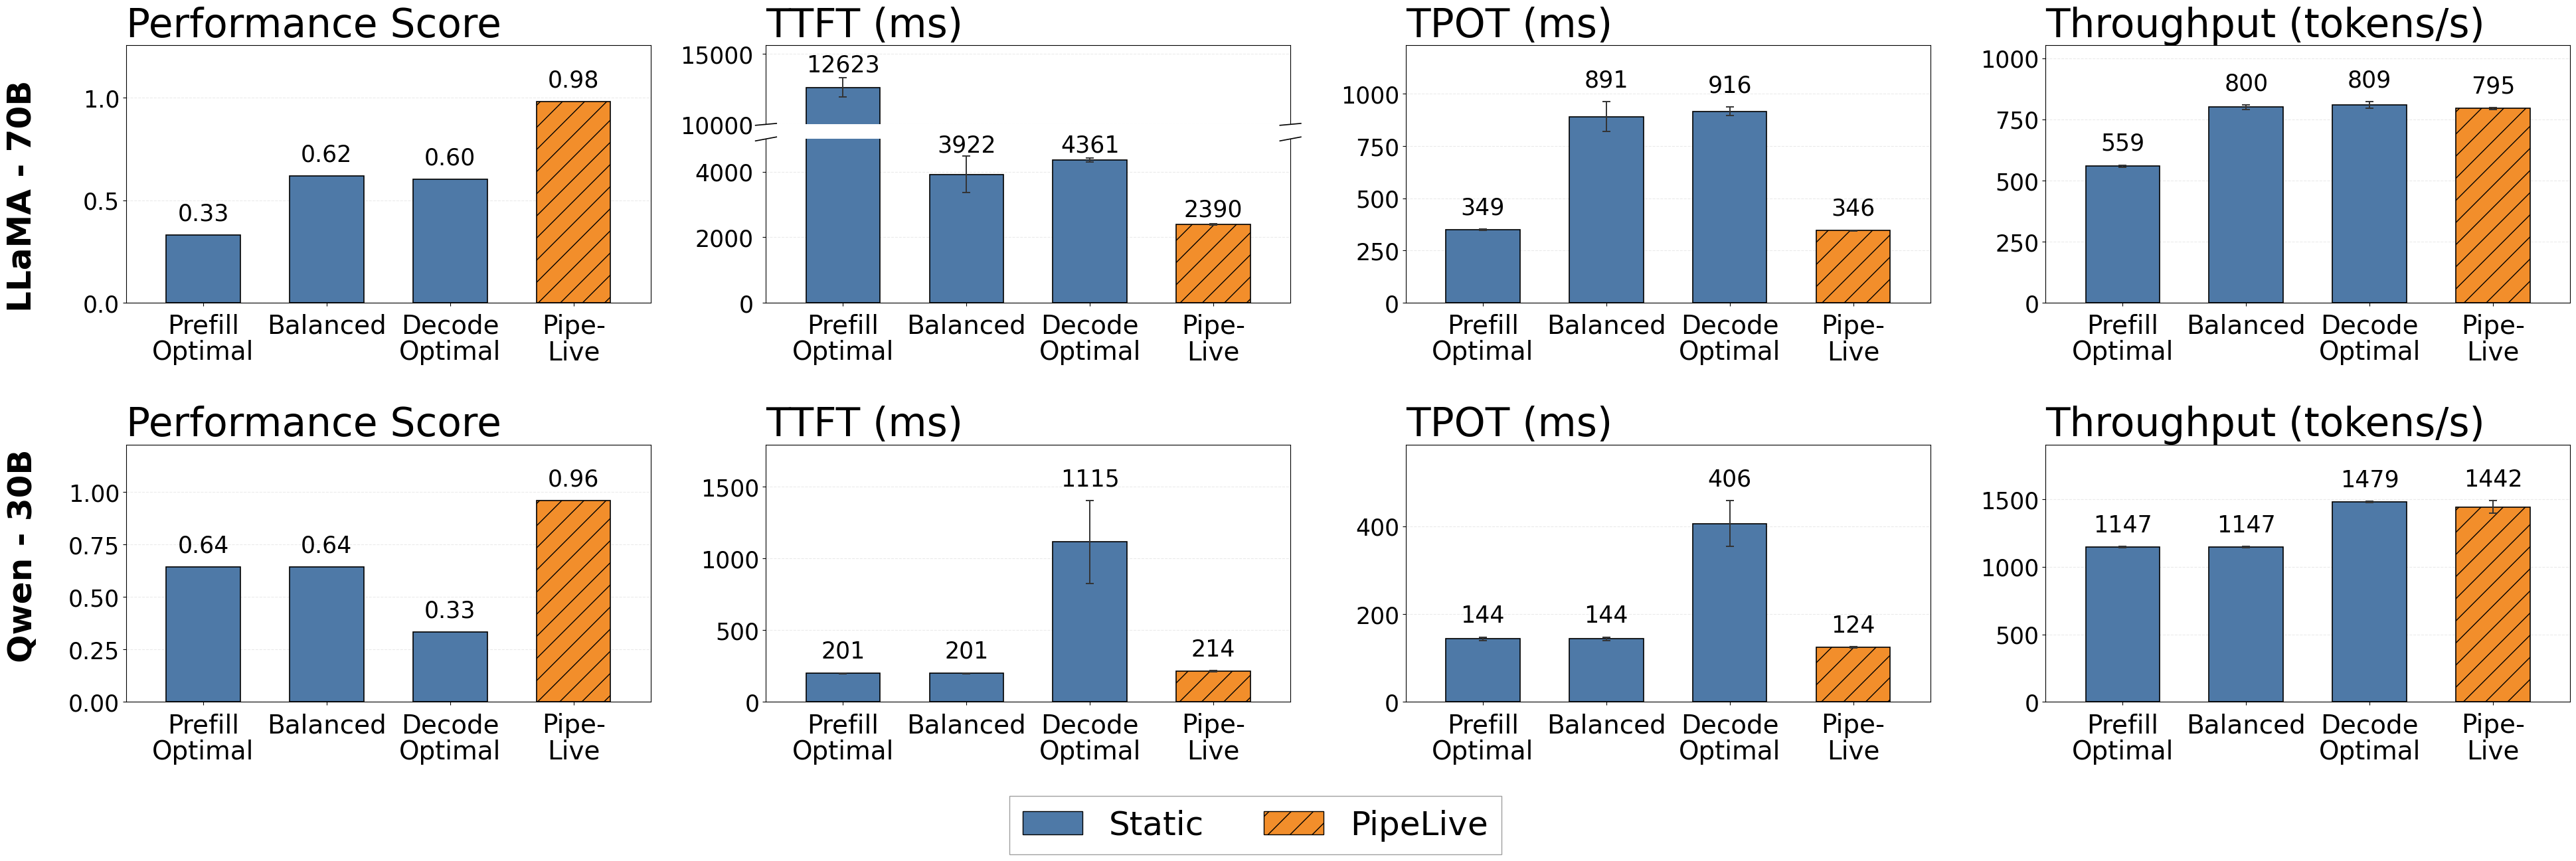

,model,kind,mig_mode,config_label,n_runs,ttft_ms,ttft_ms_std,tpot_ms,tpot_ms_std,throughput_tok_s,throughput_tok_s_std,overall_score
0,LLaMA,Static,async,36-44,5,12622.97,669.39,349.46,2.29,558.58,4.70,0.33
1,LLaMA,Static,async,48-32,5,3921.72,552.64,890.51,71.08,799.78,8.71,0.62
2,LLaMA,Static,async,52-28,5,4361.35,61.76,915.71,21.35,808.85,12.97,0.60
3,LLaMA,Migration,async,36-44 -> 52-28,3,2390.24,15.30,345.85,2.29,794.84,3.65,0.98
4,Qwen,Static,async,12-52,5,200.84,2.46,143.87,3.79,1146.69,2.84,0.64
5,Qwen,Static,async,12-52,5,200.84,2.46,143.87,3.79,1146.69,2.84,0.64
6,Qwen,Static,async,36-28,5,1115.05,287.08,406.36,51.70,1479.21,5.92,0.33
7,Qwen,Migration,async,12-52 -> 36-28,5,214.31,3.65,124.24,1.71,1441.64,46.19,0.96


In [ ]:
from pathlib import Path

import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

if "discover_experiment_metrics" not in globals():
    raise RuntimeError("请先运行第 4 个 cell，加载通用实验分析函数。")

LLAMA_CMP_DIR = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-e2e-cmp-llama-6")
QWEN_CMP_DIR = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-e2e-cmp-qwen-3")

# ---------- 带 std 的实验指标发现 ----------

REP_SUFFIX_PATTERN = re.compile(r"\.rep(\d+)$")
STYLE_MAP = {
    "Static": {"facecolor": "#4E79A7", "hatch": "", "legend": "Static"},
    "Migration": {"facecolor": "#F28E2B", "hatch": "/", "legend": "PipeLive"},
}
LLAMA_NAME_MAP = {
    "36-44": "Prefill Optimal",
    "48-32": "Balanced",
    "52-28": "Decode Optimal",
}
QWEN_NAME_MAP = {
    "12-52": "Balanced",
    "36-28": "Decode Optimal",
}

FONT_SCALE = 1.65
AXIS_LABEL_FONT = int(round(18 * FONT_SCALE))
METRIC_TITLE_FONT = int(round(26 * FONT_SCALE))
XTICK_FONT = int(round(17 * FONT_SCALE))
TICK_FONT = int(round(15 * FONT_SCALE))
ANNOTATION_FONT = int(round(15 * FONT_SCALE))
LEGEND_FONT = int(round(22 * FONT_SCALE))
ROW_LABEL_FONT = int(round(22 * FONT_SCALE))
BAR_WIDTH = 0.60
BROKEN_PANEL_HSPACE = 0.12
BROKEN_HEIGHT_RATIOS = [1.18, 2.45]


def parse_rep_index(file_name: str):
    match = REP_SUFFIX_PATTERN.search(file_name)
    return safe_int(match.group(1)) if match else None


def list_rep_files(exp_dir: Path, base_name: str):
    rep_files = []
    for path in exp_dir.glob(f"{base_name}.rep*"):
        rep_idx = parse_rep_index(path.name)
        if rep_idx is not None:
            rep_files.append((rep_idx, path))
    return sorted(rep_files, key=lambda item: item[0])


def load_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def resolve_base_config(exp_dir: Path):
    default_config_path = exp_dir / "benchmark_config.json"
    if default_config_path.exists():
        return load_json_file(default_config_path)

    rep_config_files = list_rep_files(exp_dir, "benchmark_config.json")
    if rep_config_files:
        return load_json_file(rep_config_files[0][1])

    raise FileNotFoundError(f"在 {exp_dir} 下未找到 benchmark_config.json 或 benchmark_config.json.repN")


def collect_run_metric_frames(exp_dir: Path):
    rep_request_files = list_rep_files(exp_dir, "request_metrics.csv")
    rep_config_files = dict(list_rep_files(exp_dir, "benchmark_config.json"))
    base_cfg = resolve_base_config(exp_dir)
    run_frames = []

    if rep_request_files:
        for rep_idx, request_path in rep_request_files:
            cfg = load_json_file(rep_config_files[rep_idx]) if rep_idx in rep_config_files else base_cfg
            df_run = pd.read_csv(request_path).reset_index(drop=True)
            run_frames.append((rep_idx, df_run, cfg))
        return run_frames

    request_metrics_path = exp_dir / "request_metrics.csv"
    if not request_metrics_path.exists():
        raise FileNotFoundError(f"在 {exp_dir} 下未找到 request_metrics.csv 或 request_metrics.csv.repN")

    df = pd.read_csv(request_metrics_path)
    if "repetition" in df.columns and df["repetition"].nunique() > 1:
        for rep_value, df_run in df.groupby("repetition", sort=True):
            rep_idx = safe_int(rep_value)
            cfg = load_json_file(rep_config_files[rep_idx]) if rep_idx in rep_config_files else base_cfg
            run_frames.append((rep_idx, df_run.reset_index(drop=True), cfg))
        return run_frames

    repetition = safe_int(base_cfg.get("repetition"), default=1)
    num_total_requests = safe_int(base_cfg.get("num_total_requests"), default=len(df))

    if repetition > 1 and len(df) == repetition * num_total_requests:
        for rep_idx in range(repetition):
            start = rep_idx * num_total_requests
            end = start + num_total_requests
            run_frames.append((rep_idx + 1, df.iloc[start:end].reset_index(drop=True), base_cfg))
        return run_frames

    return [(1, df.reset_index(drop=True), base_cfg)]


def parse_total_token_throughput_with_std_fallback(benchmark_log_path: Path):
    avg, std = parse_aggregate_throughput_with_std(benchmark_log_path)
    if not pd.isna(avg):
        return avg, (0.0 if pd.isna(std) else std)

    if not benchmark_log_path.exists():
        return float("nan"), float("nan")

    text = benchmark_log_path.read_text(encoding="utf-8", errors="ignore")
    single_run_patterns = [
        r"Total Token throughput \(tok/s\):\s+([0-9]+(?:\.[0-9]+)?)",
        r"TOTAL TOKEN THROUGHPUT \(tokens/s\):\s*\n\s*Average:\s+([0-9]+(?:\.[0-9]+)?)",
    ]

    for pattern in single_run_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return float(match.group(1)), 0.0

    return float("nan"), float("nan")


def compute_experiment_metrics_with_std(exp_dir: Path, params: dict):
    benchmark_log_path = exp_dir / "benchmark.log"
    run_frames = collect_run_metric_frames(exp_dir)
    metrics_df = pd.DataFrame(
        [compute_run_metrics(df_run, cfg) for _, df_run, cfg in run_frames]
    )

    mig_enabled = params.get("mig") == "1"
    source_pp = params.get("pp", "unknown")
    target_pp = params.get("tgt_pp")
    pp_left, pp_right = parse_pp_config(source_pp)
    tgt_left, tgt_right = parse_pp_config(target_pp) if target_pp else (-1, -1)
    itl_ms = parse_benchmark_metric_ms(benchmark_log_path, "Mean ITL (ms)")
    throughput_avg, throughput_std = parse_total_token_throughput_with_std_fallback(benchmark_log_path)

    if pd.isna(throughput_avg):
        throughput_avg = metrics_df["throughput_tok_s"].mean()
        throughput_std = metrics_df["throughput_tok_s"].std() if len(metrics_df) > 1 else 0.0

    result = {
        "rr": safe_int(params.get("rr")),
        "kind": "Migration" if mig_enabled else "Static",
        "mig": 1 if mig_enabled else 0,
        "pp": source_pp,
        "tgt_pp": target_pp or "-",
        "config_label": source_pp if not mig_enabled else f"{source_pp} -> {target_pp}",
        "pp_left": pp_left,
        "pp_right": pp_right,
        "tgt_left": tgt_left,
        "tgt_right": tgt_right,
        "n_req": safe_int(params.get("n_req")),
        "chunk": safe_int(params.get("chunk")),
        "rep": safe_int(params.get("rep"), default=len(run_frames)),
        "n_runs": len(metrics_df),
        "itl_ms": itl_ms,
        "selected_dir": exp_dir.name,
    }

    for col in ["ttft_ms", "tpot_ms", "normalized_latency_ms"]:
        result[col] = metrics_df[col].mean()
        result[f"{col}_std"] = metrics_df[col].std() if len(metrics_df) > 1 else 0.0

    result["throughput_tok_s"] = throughput_avg
    result["throughput_tok_s_std"] = throughput_std
    return result


def discover_experiment_metrics_with_std(base_dir: Path, required_params=None):
    required_params = {k: str(v) for k, v in (required_params or {}).items()}
    records = []

    for child in sorted(base_dir.iterdir()):
        if not child.is_dir() or not child.name.startswith("test-"):
            continue
        params = parse_test_dir_params(child.name)
        if not all(params.get(k) == v for k, v in required_params.items()):
            continue

        has_request_metrics = (child / "request_metrics.csv").exists() or bool(list_rep_files(child, "request_metrics.csv"))
        has_config = (child / "benchmark_config.json").exists() or bool(list_rep_files(child, "benchmark_config.json"))
        if not has_request_metrics or not has_config:
            continue

        records.append(compute_experiment_metrics_with_std(child, params))

    if not records:
        raise FileNotFoundError(f"在 {base_dir} 下未发现可分析的实验目录")

    summary_df = pd.DataFrame(records)
    return summary_df.sort_values(
        ["rr", "mig", "pp_left", "pp_right", "tgt_left", "tgt_right"],
        ascending=[True, True, True, False, True, False],
    ).reset_index(drop=True)


def format_display_name(name: str):
    return name.replace(" ", "\n")


def compute_overall_score(cmp_df: pd.DataFrame):
    """Compute Overall Performance Score: equal-weight average of normalized TTFT, TPOT, Throughput."""
    df = cmp_df.copy()
    df["score_ttft"] = normalize_series(df["ttft_ms"], higher_is_better=False)
    df["score_tpot"] = normalize_series(df["tpot_ms"], higher_is_better=False)
    df["score_throughput"] = normalize_series(df["throughput_tok_s"], higher_is_better=True)
    df["overall_score"] = df[["score_ttft", "score_tpot", "score_throughput"]].mean(axis=1)
    return df


def prepare_cmp_df(base_dir: Path, display_name_map: dict):
    cmp_df = discover_experiment_metrics_with_std(
        base_dir, required_params={"kernel": "direct"}
    ).copy()
    cmp_df["mig_mode"] = cmp_df["selected_dir"].map(
        lambda name: parse_test_dir_params(name).get("mig_mode", "-")
    )

    mode_order = {"-": 0, "async_fast": 1, "async": 2, "sync": 3}
    cmp_df = cmp_df.sort_values(
        ["mig", "pp_left", "pp_right", "mig_mode"],
        key=lambda col: col.map(mode_order) if col.name == "mig_mode" else col,
    ).reset_index(drop=True)

    static_df = cmp_df[cmp_df["kind"] == "Static"].drop_duplicates(subset=["pp"], keep="first")
    # 只保留 display_name_map 中明确列出的 static 配置
    static_df = static_df[static_df["pp"].isin(display_name_map.keys())]

    mig_df = cmp_df[(cmp_df["kind"] == "Migration") & (cmp_df["mig_mode"] == "async")].copy()
    if not mig_df.empty:
        mig_df = mig_df.sort_values(["n_runs", "rep", "chunk"], ascending=[False, False, False])
        mig_df = mig_df.drop_duplicates(subset=["pp", "tgt_pp", "mig_mode"], keep="first")

    cmp_df = pd.concat([static_df, mig_df], ignore_index=True)
    cmp_df = cmp_df.sort_values(["mig", "pp_left", "pp_right"]).reset_index(drop=True)

    def build_label(row):
        if row["kind"] == "Static":
            display_name = format_display_name(display_name_map.get(row["pp"], row["pp"]))
            return display_name
        return "Pipe-\nLive"

    cmp_df["label"] = cmp_df.apply(build_label, axis=1)
    cmp_df["facecolor"] = cmp_df["kind"].map(lambda kind: STYLE_MAP[kind]["facecolor"])
    cmp_df["hatch"] = cmp_df["kind"].map(lambda kind: STYLE_MAP[kind]["hatch"])

    # Compute overall performance score
    cmp_df = compute_overall_score(cmp_df)
    return cmp_df


def style_bars(bars, df_plot: pd.DataFrame):
    for bar, (_, row) in zip(bars, df_plot.iterrows()):
        bar.set_hatch(row["hatch"])

def style_xtick_labels(ax):
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")
        label.set_linespacing(1.05)


def set_top_ylabel(ax, ylabel: str, fontsize=None):
    """将 y 轴标签放到 axes 上方左对齐，替代侧面旋转标签，使排版更紧凑。"""
    if fontsize is None:
        fontsize = METRIC_TITLE_FONT
    label_text = ylabel.replace("\n", " ")
    ax.set_title(label_text, loc="left", fontsize=fontsize, pad=8)
    ax.set_ylabel("")


def draw_metric_panel(ax, df_plot: pd.DataFrame, metric_col: str, ylabel: str, fmt: str = ".0f"):
    values = pd.to_numeric(df_plot[metric_col], errors="coerce").tolist()
    std_col = f"{metric_col}_std"
    errors = (
        pd.to_numeric(df_plot[std_col], errors="coerce").fillna(0.0).tolist()
        if std_col in df_plot.columns
        else [0.0] * len(values)
    )

    bars = ax.bar(
        df_plot["label"],
        values,
        yerr=errors if any(e > 0 for e in errors) else None,
        capsize=4,
        error_kw={"linewidth": 1.4, "capthick": 1.4, "ecolor": "#333333"},
        color=df_plot["facecolor"].tolist(),
        edgecolor="black",
        linewidth=1.2,
        width=BAR_WIDTH,
    )
    style_bars(bars, df_plot)

    set_top_ylabel(ax, ylabel)
    ax.tick_params(axis="x", rotation=0, labelsize=XTICK_FONT, pad=8)
    ax.tick_params(axis="y", labelsize=TICK_FONT)
    style_xtick_labels(ax)
    ax.margins(x=0.09)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    y_max = max(v + e for v, e in zip(values, errors)) if values else 0.0
    headroom = max(y_max * 0.28, 0.10)
    ax.set_ylim(0, y_max + headroom if y_max > 0 else 1)

    for bar, value, err in zip(bars, values, errors):
        text_y = min(value + err + headroom * 0.18, y_max + headroom * 0.58)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            text_y,
            f"{value:{fmt}}",
            ha="center",
            va="bottom",
            fontsize=ANNOTATION_FONT,
        )


def draw_break_marks(ax_top, ax_bottom, d=0.012, w=0.02):
    kwargs = dict(color="k", clip_on=False, linewidth=1.2)
    ax_top.plot((-w, +w), (-d, +d), transform=ax_top.transAxes, **kwargs)
    ax_top.plot((1 - w, 1 + w), (-d, +d), transform=ax_top.transAxes, **kwargs)
    ax_bottom.plot((-w, +w), (1 - d, 1 + d), transform=ax_bottom.transAxes, **kwargs)
    ax_bottom.plot((1 - w, 1 + w), (1 - d, 1 + d), transform=ax_bottom.transAxes, **kwargs)


def draw_broken_metric_panel(
    ax_top,
    ax_bottom,
    df_plot: pd.DataFrame,
    metric_col: str,
    ylabel: str,
    lower_ylim=(0, 5000),
    upper_ylim=None,
    ylabel_x=-0.17,
    ylabel_y=0.60,
):
    values = pd.to_numeric(df_plot[metric_col], errors="coerce").tolist()
    std_col = f"{metric_col}_std"
    errors = (
        pd.to_numeric(df_plot[std_col], errors="coerce").fillna(0.0).tolist()
        if std_col in df_plot.columns
        else [0.0] * len(values)
    )

    if upper_ylim is None:
        upper_candidates = [v + e for v, e in zip(values, errors) if v + e > lower_ylim[1]]
        upper_end = max(upper_candidates) * 1.15 if upper_candidates else lower_ylim[1] * 1.2
        upper_ylim = (10000, upper_end)

    common_bar_kwargs = dict(
        yerr=errors,
        capsize=4,
        error_kw={"linewidth": 1.4, "capthick": 1.4, "ecolor": "#333333"},
        color=df_plot["facecolor"].tolist(),
        edgecolor="black",
        linewidth=1.2,
        width=BAR_WIDTH,
    )

    bars_top = ax_top.bar(df_plot["label"], values, **common_bar_kwargs)
    bars_bottom = ax_bottom.bar(df_plot["label"], values, **common_bar_kwargs)
    style_bars(bars_top, df_plot)
    style_bars(bars_bottom, df_plot)

    ax_top.set_ylim(*upper_ylim)
    ax_bottom.set_ylim(*lower_ylim)

    label_text = ylabel.replace("\n", " ")
    ax_top.set_title(label_text, loc="left", fontsize=METRIC_TITLE_FONT, pad=8)
    ax_bottom.set_ylabel("")

    for ax in [ax_top, ax_bottom]:
        ax.grid(axis="y", linestyle="--", alpha=0.25)
        ax.set_axisbelow(True)
        ax.tick_params(axis="y", labelsize=TICK_FONT, pad=10)
        ax.margins(x=0.09)

    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_bottom.tick_params(axis="x", rotation=0, labelsize=XTICK_FONT, pad=8)
    style_xtick_labels(ax_bottom)

    ax_top.spines["bottom"].set_visible(False)
    ax_bottom.spines["top"].set_visible(False)
    draw_break_marks(ax_top, ax_bottom)

    lower_range = lower_ylim[1] - lower_ylim[0]
    upper_range = upper_ylim[1] - upper_ylim[0]
    lower_margin = max(lower_range * 0.12, 120)
    upper_margin = max(upper_range * 0.18, 220)

    for bar, value, err in zip(bars_bottom, values, errors):
        x_center = bar.get_x() + bar.get_width() / 2
        if value + err <= lower_ylim[1]:
            text_y = min(value + err + lower_margin * 0.16, lower_ylim[1] - lower_margin * 0.9)
            ax_bottom.text(
                x_center,
                text_y,
                f"{value:.0f}",
                ha="center",
                va="bottom",
                fontsize=ANNOTATION_FONT,
            )
        elif value >= upper_ylim[0]:
            text_y = min(value + err + upper_margin * 0.12, upper_ylim[1] - upper_margin * 0.8)
            ax_top.text(
                x_center,
                text_y,
                f"{value:.0f}",
                ha="center",
                va="bottom",
                fontsize=ANNOTATION_FONT,
            )


llama_cmp_df = prepare_cmp_df(LLAMA_CMP_DIR, LLAMA_NAME_MAP)
qwen_cmp_df = prepare_cmp_df(QWEN_CMP_DIR, QWEN_NAME_MAP)

# Qwen: 12-52 同时是 Prefill Optimal 和 Balanced，复制该行以显示两个标签
qwen_static_12_52 = qwen_cmp_df[(qwen_cmp_df["pp"] == "12-52") & (qwen_cmp_df["kind"] == "Static")]
if len(qwen_static_12_52) == 1:
    dup = qwen_static_12_52.copy()
    dup["label"] = format_display_name("Prefill Optimal")
    qwen_cmp_df.loc[qwen_static_12_52.index, "label"] = format_display_name("Balanced")
    qwen_cmp_df = pd.concat([dup, qwen_cmp_df], ignore_index=True)
    label_order = {
        format_display_name("Prefill Optimal"): 0,
        format_display_name("Balanced"): 1,
        format_display_name("Decode Optimal"): 2,
        "Pipe-\nLive": 3,
    }
    qwen_cmp_df["_order"] = qwen_cmp_df["label"].map(label_order).fillna(99)
    qwen_cmp_df = qwen_cmp_df.sort_values("_order").reset_index(drop=True)
    qwen_cmp_df = qwen_cmp_df.drop(columns=["_order"])

fig = plt.figure(figsize=(40, 12.6))
gs = fig.add_gridspec(2, 4, hspace=0.55, wspace=0.22)

draw_metric_panel(fig.add_subplot(gs[0, 0]), llama_cmp_df, "overall_score", "Performance Score", fmt=".2f")

llama_ttft_gs = gs[0, 1].subgridspec(
    2, 1, height_ratios=BROKEN_HEIGHT_RATIOS, hspace=BROKEN_PANEL_HSPACE
)
ax_llama_ttft_top = fig.add_subplot(llama_ttft_gs[0, 0])
ax_llama_ttft_bottom = fig.add_subplot(llama_ttft_gs[1, 0])

draw_broken_metric_panel(
    ax_llama_ttft_top,
    ax_llama_ttft_bottom,
    llama_cmp_df,
    "ttft_ms",
    "TTFT (ms)",
    lower_ylim=(0, 5000),
    upper_ylim=(10000, 15600),
)

draw_metric_panel(fig.add_subplot(gs[0, 2]), llama_cmp_df, "tpot_ms", "TPOT (ms)")
draw_metric_panel(fig.add_subplot(gs[0, 3]), llama_cmp_df, "throughput_tok_s", "Throughput (tokens/s)")

draw_metric_panel(fig.add_subplot(gs[1, 0]), qwen_cmp_df, "overall_score", "Performance Score", fmt=".2f")
draw_metric_panel(fig.add_subplot(gs[1, 1]), qwen_cmp_df, "ttft_ms", "TTFT (ms)")
draw_metric_panel(fig.add_subplot(gs[1, 2]), qwen_cmp_df, "tpot_ms", "TPOT (ms)")
draw_metric_panel(fig.add_subplot(gs[1, 3]), qwen_cmp_df, "throughput_tok_s", "Throughput (tokens/s)")

fig.text(0.036, 0.805, "LLaMA - 70B", rotation=90, va="center", ha="center", fontsize=ROW_LABEL_FONT, fontweight="bold")
fig.text(0.036, 0.375, "Qwen - 30B", rotation=90, va="center", ha="center", fontsize=ROW_LABEL_FONT, fontweight="bold")

legend_handles = [
    Patch(facecolor=STYLE_MAP["Static"]["facecolor"], edgecolor="black", hatch=STYLE_MAP["Static"]["hatch"], label=STYLE_MAP["Static"]["legend"]),
    Patch(facecolor=STYLE_MAP["Migration"]["facecolor"], edgecolor="black", hatch=STYLE_MAP["Migration"]["hatch"], label=STYLE_MAP["Migration"]["legend"]),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=True,
    fancybox=False,
    bbox_to_anchor=(0.5, -0.002),
    fontsize=LEGEND_FONT,
    handlelength=1.8,
    columnspacing=1.8,
    edgecolor="#888888",
)

fig.subplots_adjust(left=0.075, right=0.995, top=0.985, bottom=0.20)
plt.savefig("/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/e2e_llama_qwen_combined-1.pdf", dpi=220, bbox_inches="tight")
plt.show()

pd.concat(
    [
        llama_cmp_df.assign(model="LLaMA"),
        qwen_cmp_df.assign(model="Qwen"),
    ],
    ignore_index=True,
)[[
    "model", "kind", "mig_mode", "config_label", "n_runs",
    "ttft_ms", "ttft_ms_std",
    "tpot_ms", "tpot_ms_std",
    "throughput_tok_s", "throughput_tok_s_std",
    "overall_score",
]].round(2)